### Importy i Konfiguracja

In [ ]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ast import literal_eval

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

RESULTS_DIR = "experiment_results"

BKS = {
    'c101': {'dist': 828.94, 'veh': 10},
    'r101': {'dist': 1650.80, 'veh': 19},
    'rc101': {'dist': 1696.95, 'veh': 14}
}

### Funkcja Ładująca Dane
Ta funkcja przeszuka wszystkie podfoldery i stworzy jedną dużą tabelę ze wszystkimi wynikami.

In [ ]:
def load_all_experiments(base_dir):
    data = []
    
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.endswith(".json"):
                path = os.path.join(root, file)
                
                try:
                    with open(path, 'r') as f:
                        content = json.load(f)
                    
                    meta = content.get('meta', {})
                    res = content.get('results', {})
                    params = content.get('parameters', {})
                    
                    exp_name = meta.get('experiment', 'Unknown')
                    param_name = meta.get('param_changed', 'Unknown')
                    param_val = meta.get('param_value', 0)
                    instance = meta.get('instance', 'unknown')
                    run_id = meta.get('run_id', 0)
                    
                    row = {
                        'Experiment': exp_name,
                        'Parameter': param_name,
                        'Value': param_val,
                        'Instance': instance,
                        'Run_ID': run_id,
                        'Distance': res.get('final_distance'),
                        'Vehicles': res.get('final_vehicles'),
                        'Cost': res.get('final_cost'),
                        'Time': res.get('execution_time'),
                        'History': content.get('history', []),
                        'Routes': content.get('routes', []),
                        'Customers': content.get('parameters', {}).get('instance_path', instance)
                    }
                    data.append(row)
                except Exception as e:
                    print(f"Błąd przy odczycie {path}: {e}")

    return pd.DataFrame(data)

df = load_all_experiments(RESULTS_DIR)
print(f"Załadowano {len(df)} pojedynczych uruchomień")
df.head()

Załadowano 180 pojedynczych uruchomień.


,Experiment,Parameter,Value,Instance,Run_ID,Distance,Vehicles,Cost,Time,History,Routes,Customers
0,Exp1_Kill_Aggression,w_kill,0,c101,1,1298.093791,12,121298.093791,2.131569,"[{'iter': 0, 'cost': 121500.34554418676, 'dist...","[[0, 87, 86, 83, 82, 11, 9, 6, 4, 75, 0], [0, ...",c101.txt
1,Exp1_Kill_Aggression,w_kill,0,c101,2,1175.313707,12,121177.885251,2.113912,"[{'iter': 0, 'cost': 121500.34554418676, 'dist...","[[0, 5, 3, 7, 8, 10, 11, 9, 6, 4, 0], [0, 20, ...",c101.txt
2,Exp1_Kill_Aggression,w_kill,0,c101,3,1250.724507,12,121253.761075,2.180162,"[{'iter': 0, 'cost': 121500.34554418676, 'dist...","[[0, 90, 87, 86, 83, 82, 84, 85, 88, 2, 1, 0],...",c101.txt
3,Exp1_Kill_Aggression,w_kill,0,c101,4,1435.773872,12,121435.773872,2.129439,"[{'iter': 0, 'cost': 121500.34554418676, 'dist...","[[0, 5, 3, 7, 8, 10, 16, 14, 12, 21, 0], [0, 2...",c101.txt
4,Exp1_Kill_Aggression,w_kill,0,c101,5,1248.199824,12,121248.199824,2.085600,"[{'iter': 0, 'cost': 121500.34554418676, 'dist...","[[0, 5, 3, 7, 8, 10, 16, 14, 12, 0], [0, 20, 2...",c101.txt


### Statystyki i Tabela Wyników
Tu generujemy tabelę z: Najlepszym, Najgorszym, Średnim wynikiem, Odchyleniem Std i Czasem.

In [ ]:
stats = df.groupby(['Experiment', 'Parameter', 'Value', 'Instance']).agg({
    'Distance': ['min', 'max', 'mean', 'std'],
    'Vehicles': ['min', 'mean'],
    'Time': 'mean'
}).reset_index()

stats.columns = ['_'.join(col).strip() if col[1] else col[0] for col in stats.columns.values]

def calculate_gap(row):
    inst = row['Instance']
    if inst in BKS:
        bks_dist = BKS[inst]['dist']
        my_dist = row['Distance_min']
        return ((my_dist - bks_dist) / bks_dist) * 100
    return None

stats['BKS_Dist'] = stats['Instance'].apply(lambda x: BKS.get(x, {}).get('dist'))
stats['GAP_%'] = stats.apply(calculate_gap, axis=1)

pd.options.display.float_format = '{:.2f}'.format
display(stats[['Experiment', 'Value', 'Instance', 'Distance_min', 'Distance_mean', 'Distance_std', 'Vehicles_min', 'Time_mean', 'GAP_%']])

,Experiment,Value,Instance,Distance_min,Distance_mean,Distance_std,Vehicles_min,Time_mean,GAP_%
0,Exp1_Kill_Aggression,0,c101,1175.31,1281.62,96.70,12,2.13,42.07
1,Exp1_Kill_Aggression,0,r101,1698.66,1734.04,30.96,20,1.87,3.72
2,Exp1_Kill_Aggression,0,rc101,1774.39,1828.91,46.61,17,1.96,9.57
3,Exp1_Kill_Aggression,1,c101,1259.55,1409.08,95.91,12,6.59,52.25
4,Exp1_Kill_Aggression,1,r101,1715.53,1747.67,36.35,20,5.60,4.75
5,Exp1_Kill_Aggression,1,rc101,1805.53,1868.78,57.12,16,5.82,11.49
6,Exp1_Kill_Aggression,10,c101,1152.71,1355.32,139.63,11,42.73,39.33
7,Exp1_Kill_Aggression,10,r101,1733.60,1794.81,39.35,19,20.03,5.86
8,Exp1_Kill_Aggression,10,rc101,1886.56,1917.20,30.48,16,22.02,16.50
9,Exp2_2opt_Smoothing,0,c101,1068.42,1201.52,91.83,11,7.94,29.15


### Wykresy Porównawcze Parametrów (Boxploty)
To pokaże "wpływ poszczególnych parametrów na jakość rozwiązania" oraz "stabilność" (wysokość pudełka).

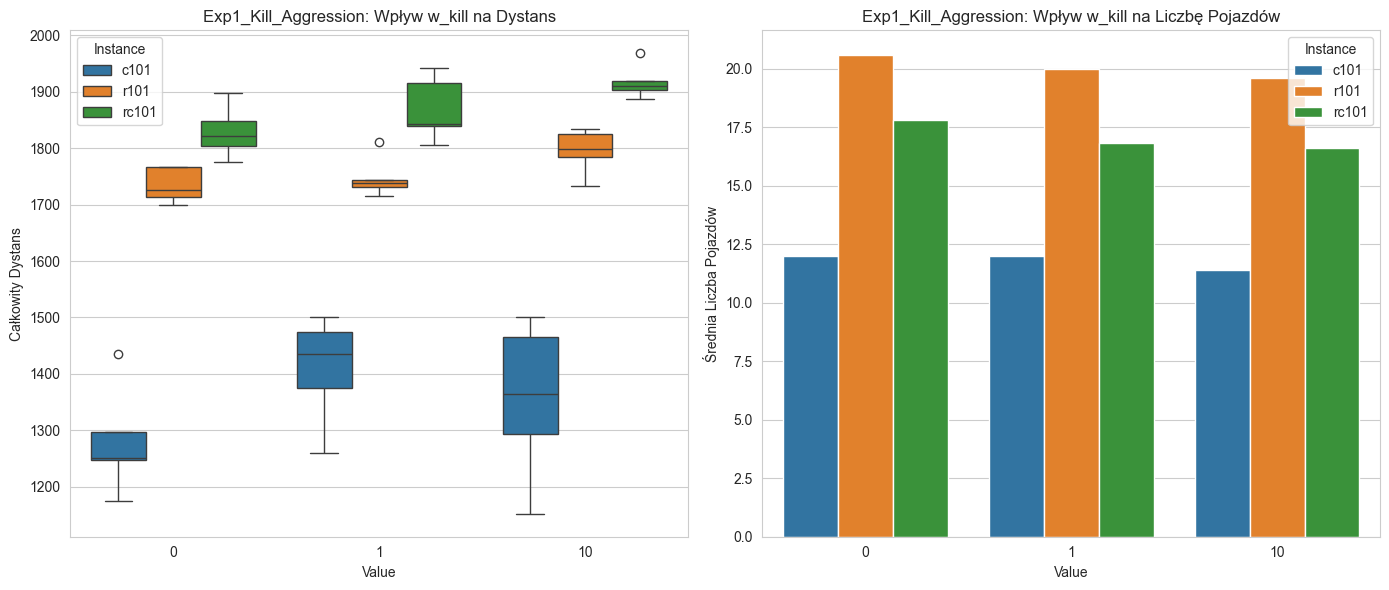

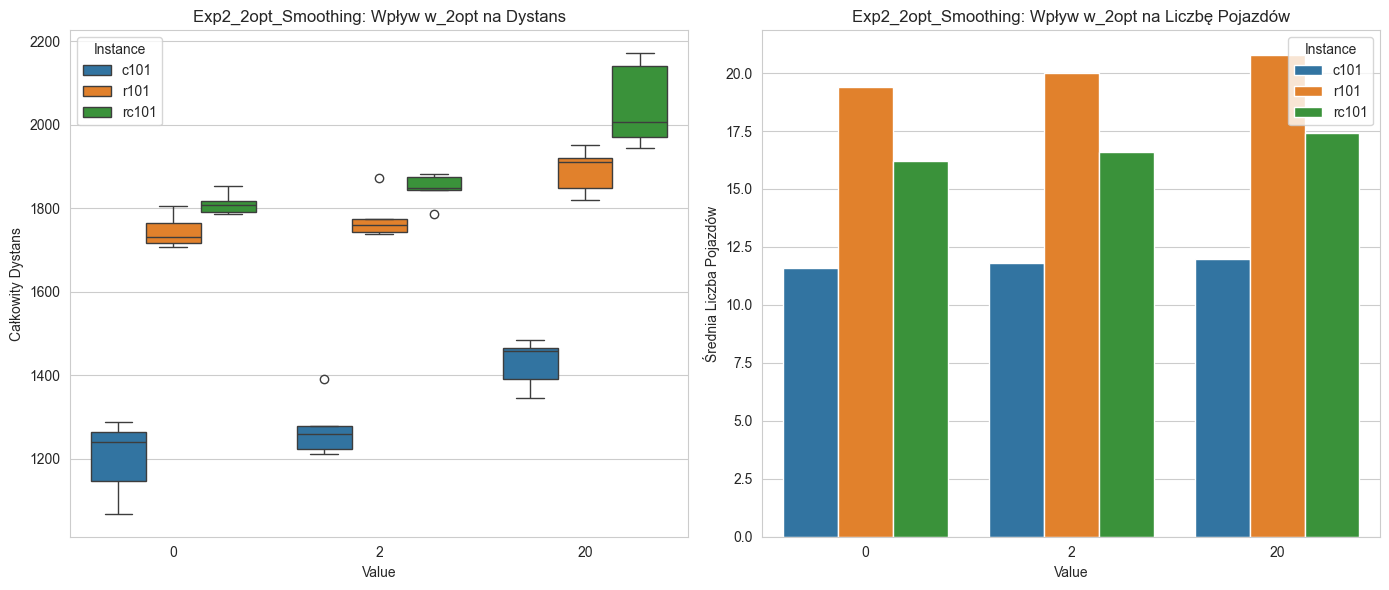

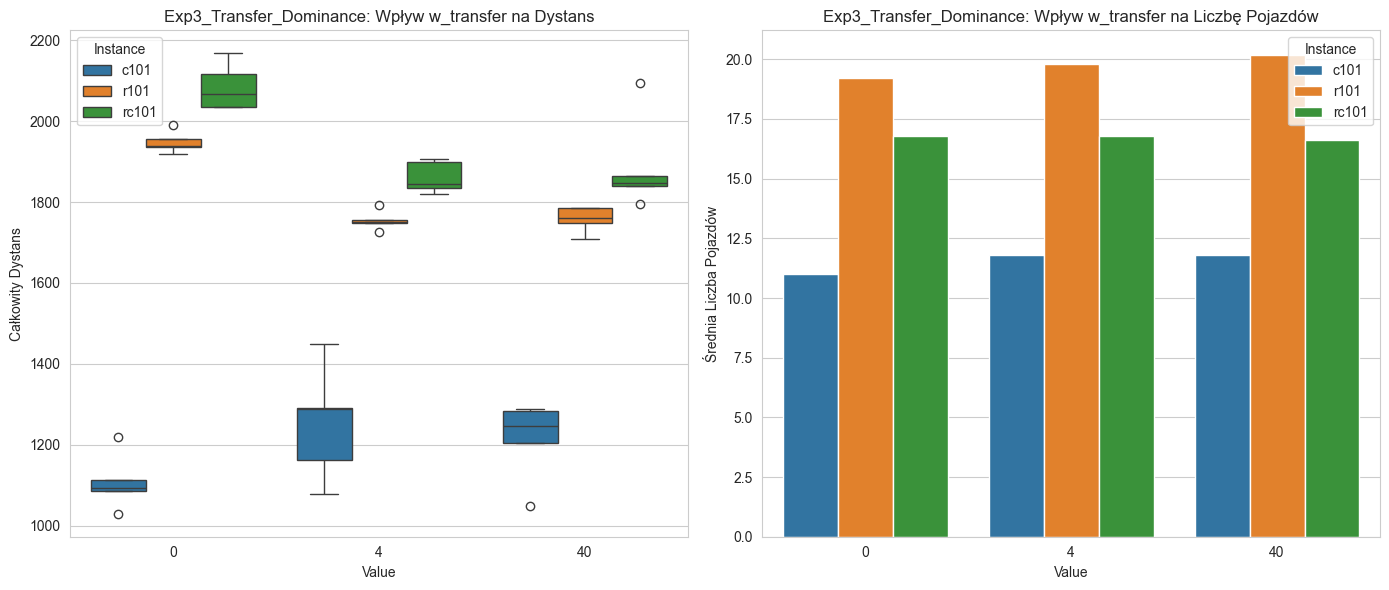

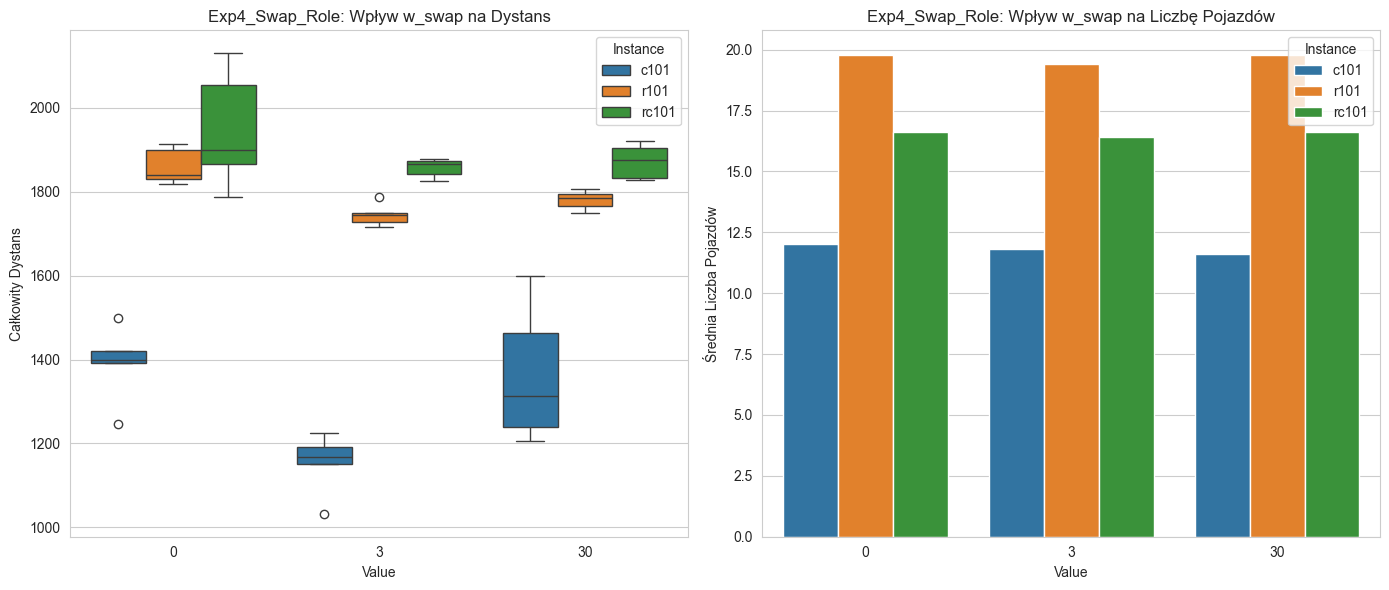

In [ ]:
unique_experiments = df['Experiment'].unique()

for exp in unique_experiments:
    exp_data = df[df['Experiment'] == exp]
    param_name = exp_data['Parameter'].iloc[0]
    
    plt.figure(figsize=(14, 6))
    
    plt.subplot(1, 2, 1)
    sns.boxplot(x='Value', y='Distance', hue='Instance', data=exp_data)
    plt.title(f'{exp}: Wpływ {param_name} na Dystans')
    plt.ylabel('Całkowity Dystans')
    
    plt.subplot(1, 2, 2)
    sns.barplot(x='Value', y='Vehicles', hue='Instance', data=exp_data, errorbar=None)
    plt.title(f'{exp}: Wpływ {param_name} na Liczbę Pojazdów')
    plt.ylabel('Średnia Liczba Pojazdów')
    
    plt.tight_layout()
    plt.show()

### Wykresy Zbieżności (Convergence)
Pokaże, jak zmieniał się koszt w czasie. Wybieramy jedną, reprezentatywną konfigurację (np. środkową wartość parametru) i pokazujemy wszystkie 5 uruchomień.

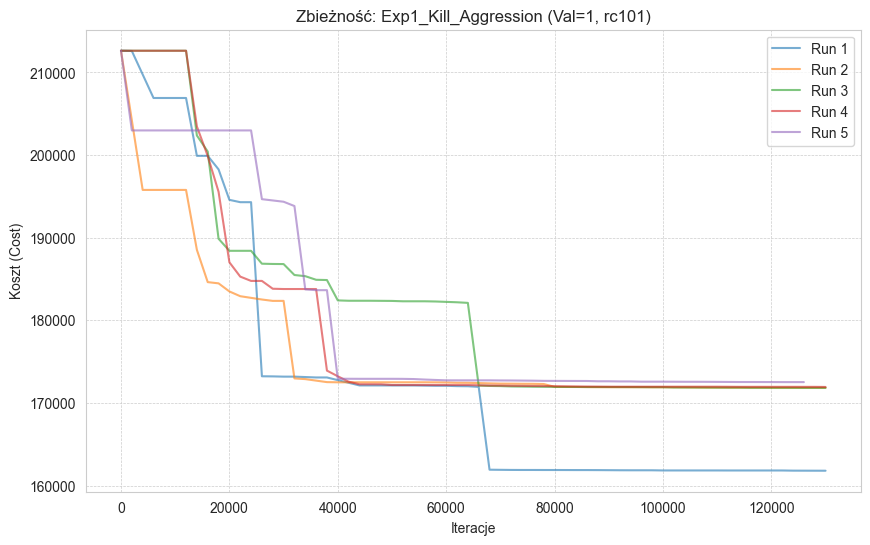

In [ ]:
def plot_convergence(df, experiment_name, param_value, instance_name):
    subset = df[
        (df['Experiment'] == experiment_name) & 
        (df['Value'] == param_value) & 
        (df['Instance'] == instance_name)
    ]
    
    if subset.empty:
        print("Brak danych dla podanych kryteriów.")
        return

    plt.figure(figsize=(10, 6))
    
    for _, row in subset.iterrows():
        history = row['History']
        iters = [h['iter'] for h in history]
        costs = [h['cost'] for h in history]
        plt.plot(iters, costs, alpha=0.6, label=f"Run {row['Run_ID']}")

    plt.title(f"Zbieżność: {experiment_name} (Val={param_value}, {instance_name})")
    plt.xlabel("Iteracje")
    plt.ylabel("Koszt (Cost)")
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()

plot_convergence(df, "Exp1_Kill_Aggression", 1, "rc101")

### Wizualizacja Tras (Najlepsza vs Najgorsza)
Skrypt zapisuje routes jako listę ID klientów. Aby to narysować w Notebooku, musimy wczytać plik rc101.txt raz jeszcze, żeby znać współrzędne X, Y dla ID.

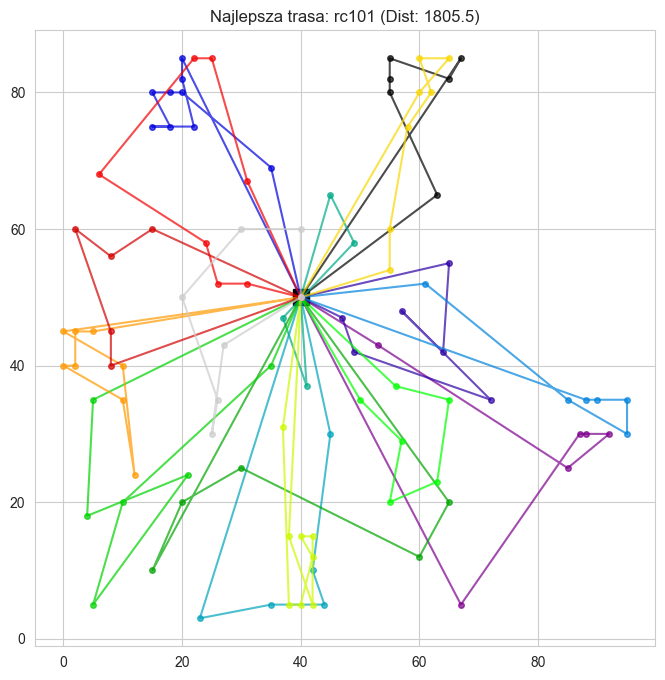

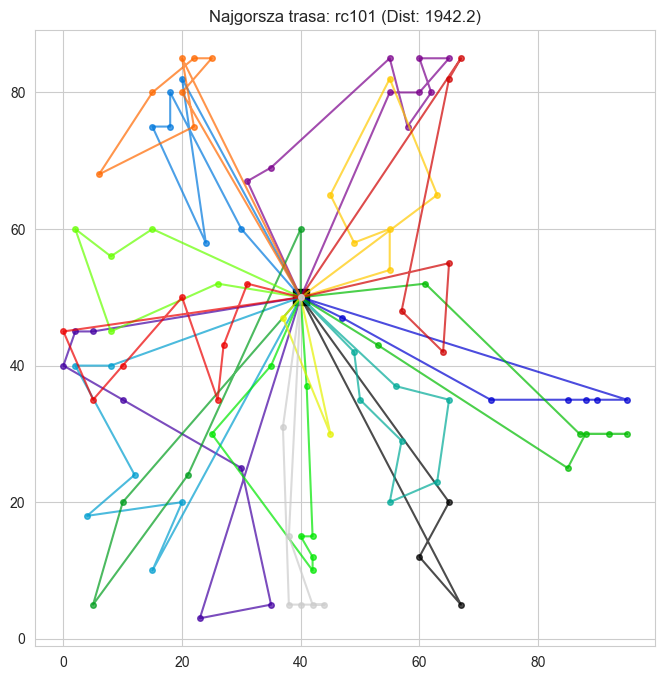

In [9]:
class CustomerNode:
    def __init__(self, idx, x, y):
        self.id = idx; self.x = x; self.y = y

def load_coords(instance_name):
    path = f"{instance_name}.txt"
    coords = {}
    if not os.path.exists(path):
        print(f"Brak pliku {path}, nie można narysować trasy.")
        return None
    
    with open(path, 'r') as f:
        lines = [l.strip() for l in f.readlines() if l.strip()]
    
    iterator = iter(lines)
    found_coord = False
    while True:
        try:
            line = next(iterator)
            if "CUST NO." in line:
                found_coord = True; continue
            if not found_coord: continue
            
            parts = line.split()
            if not parts[0].isdigit(): continue
            cid, x, y = int(parts[0]), int(parts[1]), int(parts[2])
            coords[cid] = CustomerNode(cid, x, y)
        except StopIteration:
            break
    return coords

def viz_routes_notebook(routes, coords, title):
    if not coords: return
    plt.figure(figsize=(8, 8))
    depot = coords[0]
    plt.plot(depot.x, depot.y, 'ks', markersize=12, label='Depot')
    
    colors = plt.cm.nipy_spectral(np.linspace(0, 1, len(routes)))
    
    for i, route in enumerate(routes):
        if len(route) <= 2: continue
        X = [coords[cid].x for cid in route]
        Y = [coords[cid].y for cid in route]
        plt.plot(X, Y, 'o-', color=colors[i], markersize=4, alpha=0.7)
        
    plt.title(title)
    plt.show()


EXP = "Exp1_Kill_Aggression"
VAL = 1
INST = "rc101"

subset = df[(df['Experiment'] == EXP) & (df['Value'] == VAL) & (df['Instance'] == INST)]
coords = load_coords(INST)

if not subset.empty and coords:
    # Najlepszy wynik w tej serii
    best_run = subset.loc[subset['Distance'].idxmin()]
    viz_routes_notebook(best_run['Routes'], coords, f"Najlepsza trasa: {INST} (Dist: {best_run['Distance']:.1f})")
    
    # Najgorszy wynik w tej serii
    worst_run = subset.loc[subset['Distance'].idxmax()]
    viz_routes_notebook(worst_run['Routes'], coords, f"Najgorsza trasa: {INST} (Dist: {worst_run['Distance']:.1f})")

## Exp1_Kill_Aggression

RC101 wizualizacja Exp1_Kill_Aggression

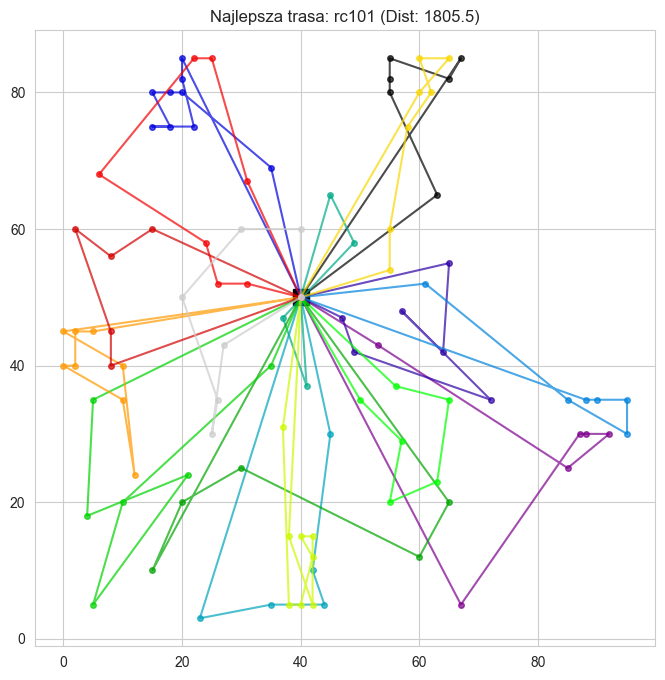

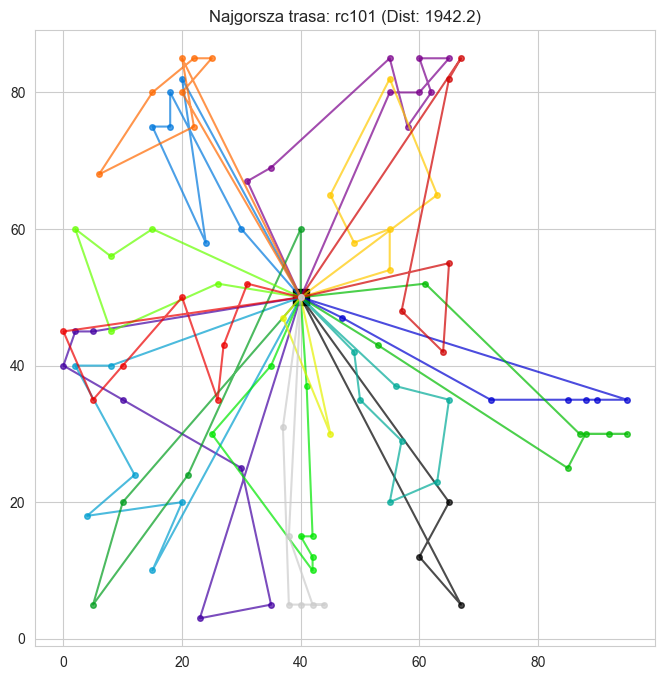

In [10]:

EXP = "Exp1_Kill_Aggression"
VAL = 1
INST = "rc101"

subset = df[(df['Experiment'] == EXP) & (df['Value'] == VAL) & (df['Instance'] == INST)]
coords = load_coords(INST)

if not subset.empty and coords:
    # Najlepszy wynik w tej serii
    best_run = subset.loc[subset['Distance'].idxmin()]
    viz_routes_notebook(best_run['Routes'], coords, f"Najlepsza trasa: {INST} (Dist: {best_run['Distance']:.1f})")
    
    # Najgorszy wynik w tej serii
    worst_run = subset.loc[subset['Distance'].idxmax()]
    viz_routes_notebook(worst_run['Routes'], coords, f"Najgorsza trasa: {INST} (Dist: {worst_run['Distance']:.1f})")

R101 wizualizacja Exp1_Kill_Aggression

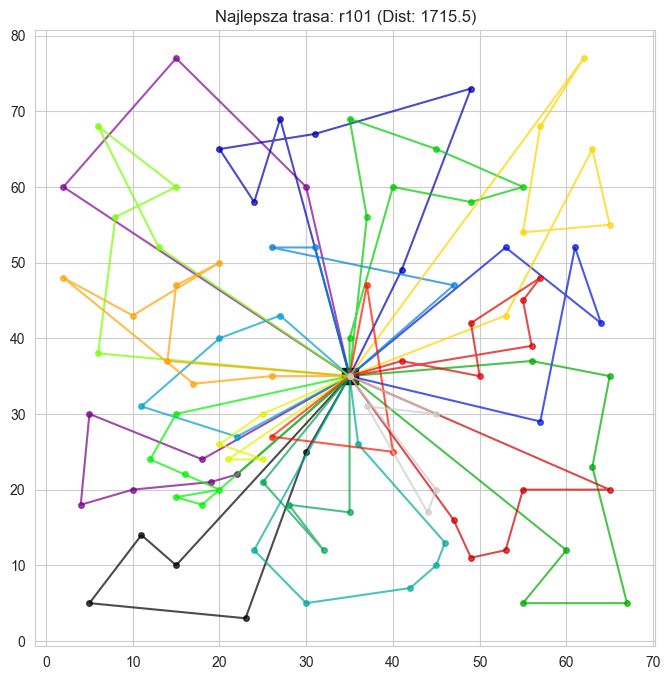

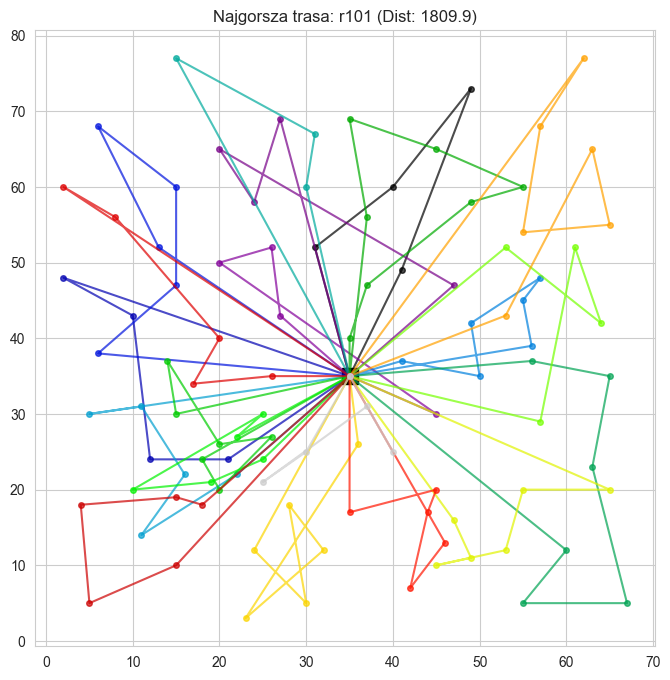

In [24]:

EXP = "Exp1_Kill_Aggression"
VAL = 1
INST = "r101"

subset = df[(df['Experiment'] == EXP) & (df['Value'] == VAL) & (df['Instance'] == INST)]
coords = load_coords(INST)

if not subset.empty and coords:
    # Najlepszy wynik w tej serii
    best_run = subset.loc[subset['Distance'].idxmin()]
    viz_routes_notebook(best_run['Routes'], coords, f"Najlepsza trasa: {INST} (Dist: {best_run['Distance']:.1f})")
    
    # Najgorszy wynik w tej serii
    worst_run = subset.loc[subset['Distance'].idxmax()]
    viz_routes_notebook(worst_run['Routes'], coords, f"Najgorsza trasa: {INST} (Dist: {worst_run['Distance']:.1f})")

C101 wizualizacja Exp1_Kill_Aggression

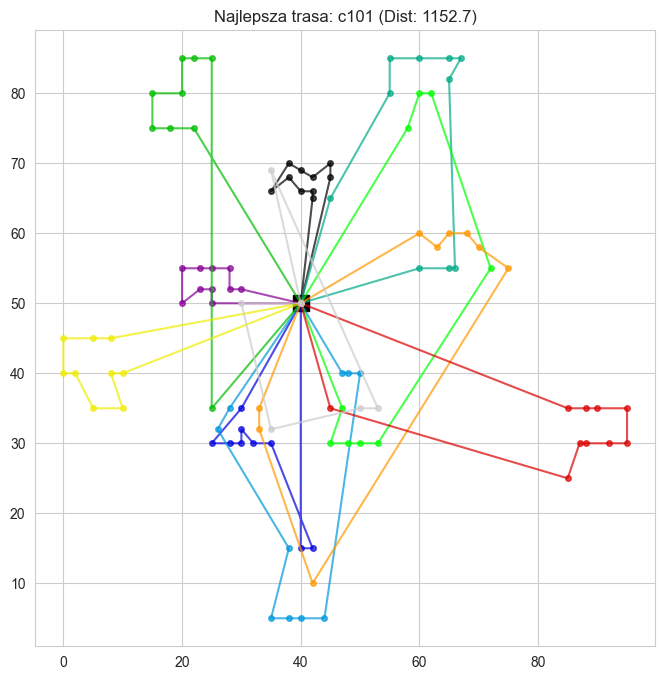

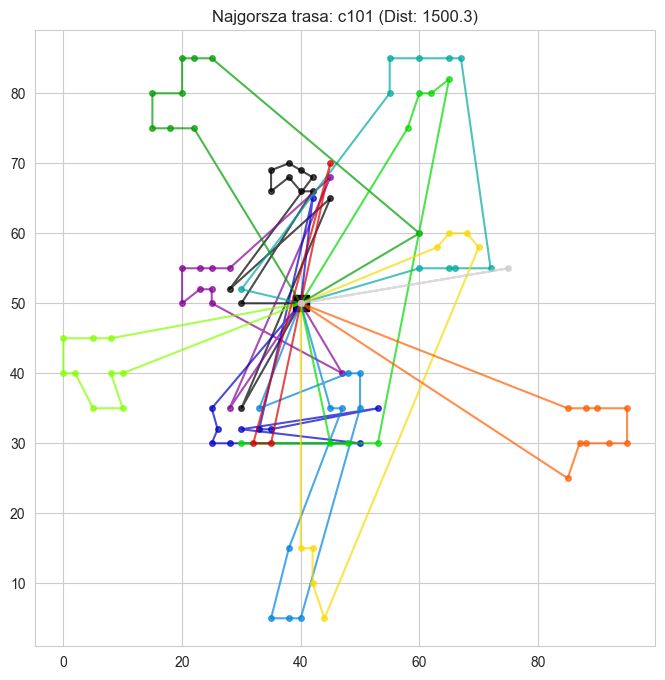

In [29]:

EXP = "Exp1_Kill_Aggression"
VAL = 10
INST = "c101"

subset = df[(df['Experiment'] == EXP) & (df['Value'] == VAL) & (df['Instance'] == INST)]
coords = load_coords(INST)

if not subset.empty and coords:
    # Najlepszy wynik w tej serii
    best_run = subset.loc[subset['Distance'].idxmin()]
    viz_routes_notebook(best_run['Routes'], coords, f"Najlepsza trasa: {INST} (Dist: {best_run['Distance']:.1f})")
    
    # Najgorszy wynik w tej serii
    worst_run = subset.loc[subset['Distance'].idxmax()]
    viz_routes_notebook(worst_run['Routes'], coords, f"Najgorsza trasa: {INST} (Dist: {worst_run['Distance']:.1f})")

## Exp2_2opt_Smoothing

rc101 

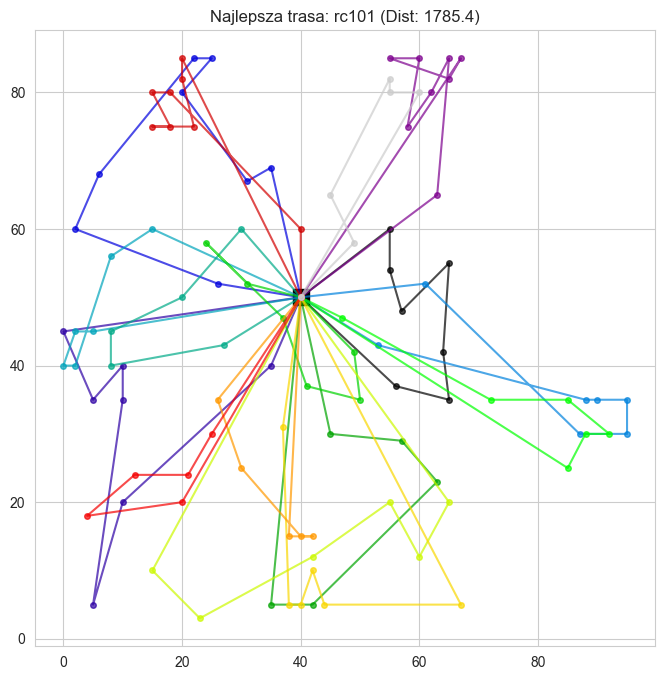

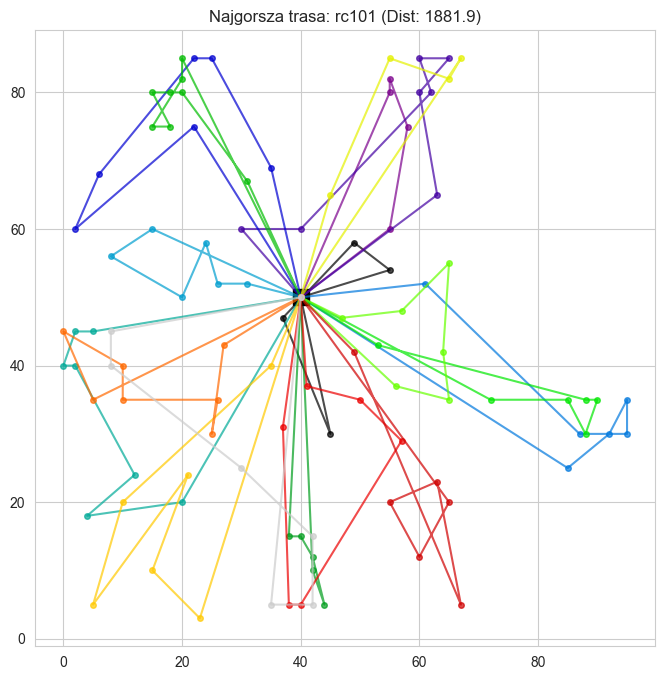

In [38]:

EXP = "Exp2_2opt_Smoothing"
VAL = 2
INST = "rc101"

subset = df[(df['Experiment'] == EXP) & (df['Value'] == VAL) & (df['Instance'] == INST)]
coords = load_coords(INST)

if not subset.empty and coords:
    # Najlepszy wynik w tej serii
    best_run = subset.loc[subset['Distance'].idxmin()]
    viz_routes_notebook(best_run['Routes'], coords, f"Najlepsza trasa: {INST} (Dist: {best_run['Distance']:.1f})")
    
    # Najgorszy wynik w tej serii
    worst_run = subset.loc[subset['Distance'].idxmax()]
    viz_routes_notebook(worst_run['Routes'], coords, f"Najgorsza trasa: {INST} (Dist: {worst_run['Distance']:.1f})")

r101

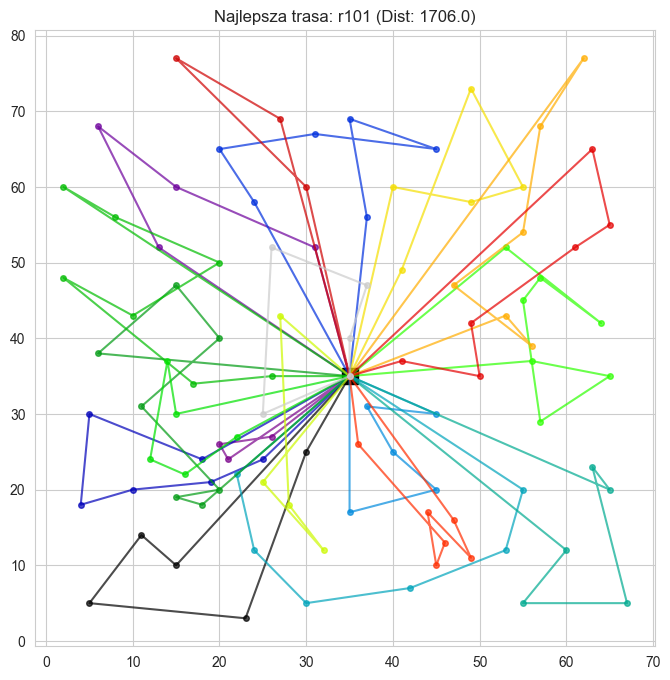

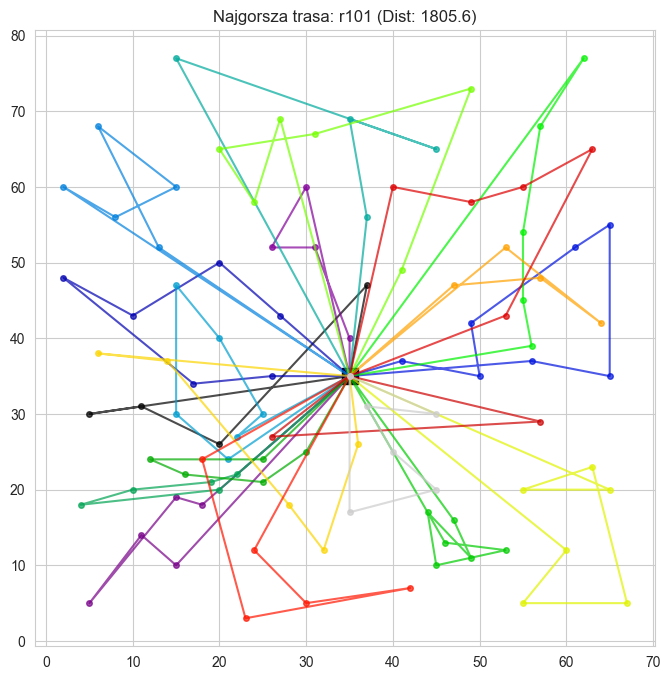

In [42]:

EXP = "Exp2_2opt_Smoothing"
VAL = 0
INST = "r101"

subset = df[(df['Experiment'] == EXP) & (df['Value'] == VAL) & (df['Instance'] == INST)]
coords = load_coords(INST)

if not subset.empty and coords:
    # Najlepszy wynik w tej serii
    best_run = subset.loc[subset['Distance'].idxmin()]
    viz_routes_notebook(best_run['Routes'], coords, f"Najlepsza trasa: {INST} (Dist: {best_run['Distance']:.1f})")
    
    # Najgorszy wynik w tej serii
    worst_run = subset.loc[subset['Distance'].idxmax()]
    viz_routes_notebook(worst_run['Routes'], coords, f"Najgorsza trasa: {INST} (Dist: {worst_run['Distance']:.1f})")

c101

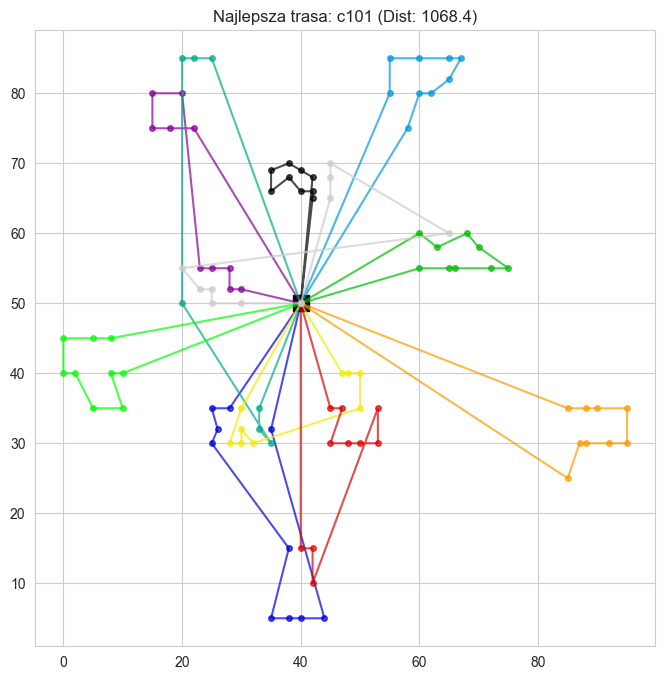

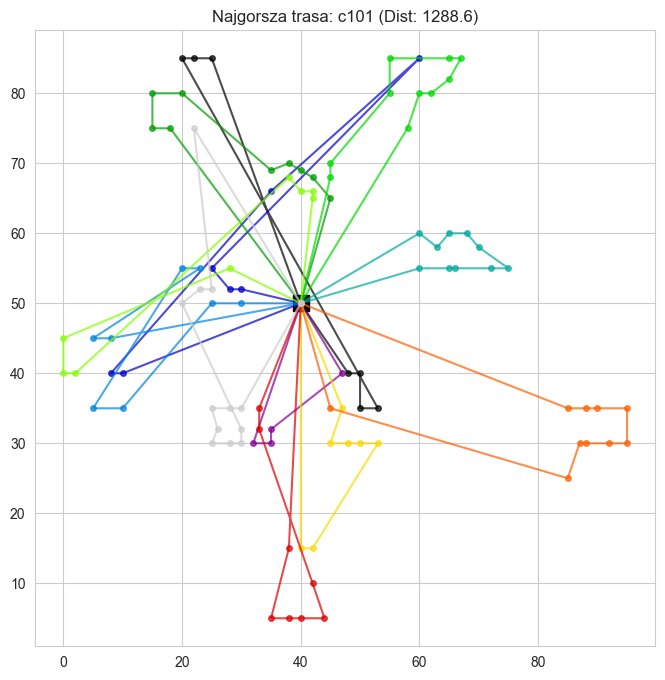

In [46]:

EXP = "Exp2_2opt_Smoothing"
VAL = 0
INST = "c101"

subset = df[(df['Experiment'] == EXP) & (df['Value'] == VAL) & (df['Instance'] == INST)]
coords = load_coords(INST)

if not subset.empty and coords:
    # Najlepszy wynik w tej serii
    best_run = subset.loc[subset['Distance'].idxmin()]
    viz_routes_notebook(best_run['Routes'], coords, f"Najlepsza trasa: {INST} (Dist: {best_run['Distance']:.1f})")
    
    # Najgorszy wynik w tej serii
    worst_run = subset.loc[subset['Distance'].idxmax()]
    viz_routes_notebook(worst_run['Routes'], coords, f"Najgorsza trasa: {INST} (Dist: {worst_run['Distance']:.1f})")

### Exp3_Transfer_Dominance

rc101

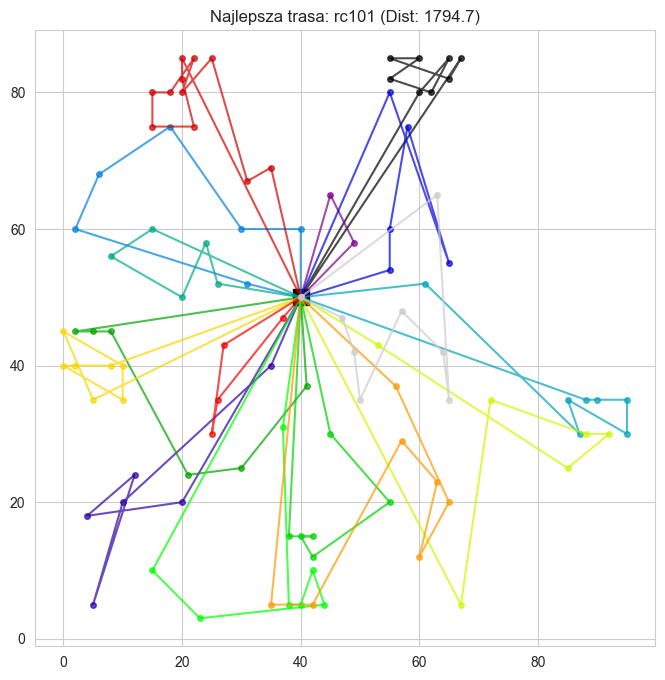

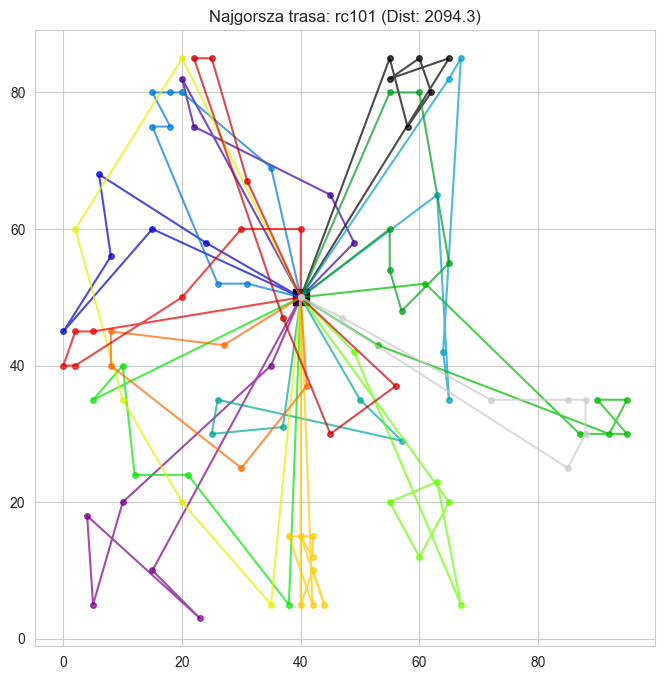

In [54]:

EXP = "Exp3_Transfer_Dominance"
VAL = 40
INST = "rc101"

subset = df[(df['Experiment'] == EXP) & (df['Value'] == VAL) & (df['Instance'] == INST)]
coords = load_coords(INST)

if not subset.empty and coords:
    # Najlepszy wynik w tej serii
    best_run = subset.loc[subset['Distance'].idxmin()]
    viz_routes_notebook(best_run['Routes'], coords, f"Najlepsza trasa: {INST} (Dist: {best_run['Distance']:.1f})")
    
    # Najgorszy wynik w tej serii
    worst_run = subset.loc[subset['Distance'].idxmax()]
    viz_routes_notebook(worst_run['Routes'], coords, f"Najgorsza trasa: {INST} (Dist: {worst_run['Distance']:.1f})")

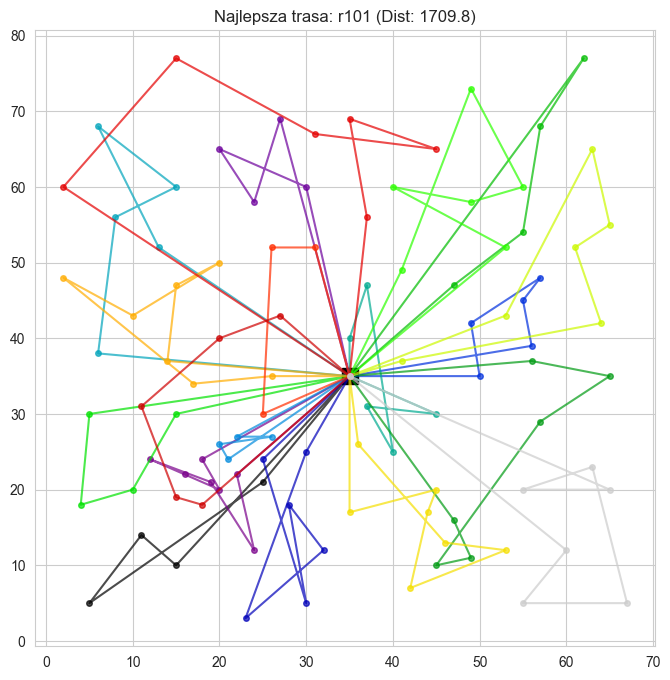

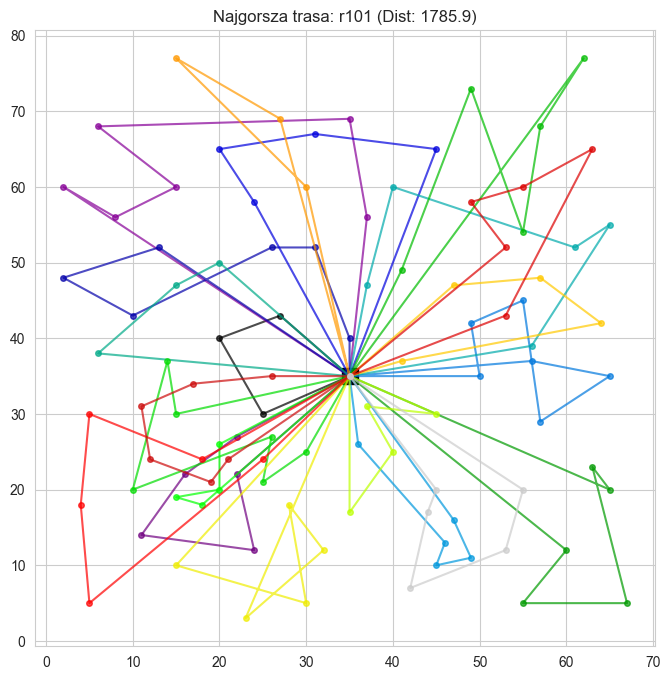

In [55]:

EXP = "Exp3_Transfer_Dominance"
VAL = 40
INST = "r101"

subset = df[(df['Experiment'] == EXP) & (df['Value'] == VAL) & (df['Instance'] == INST)]
coords = load_coords(INST)

if not subset.empty and coords:
    # Najlepszy wynik w tej serii
    best_run = subset.loc[subset['Distance'].idxmin()]
    viz_routes_notebook(best_run['Routes'], coords, f"Najlepsza trasa: {INST} (Dist: {best_run['Distance']:.1f})")
    
    # Najgorszy wynik w tej serii
    worst_run = subset.loc[subset['Distance'].idxmax()]
    viz_routes_notebook(worst_run['Routes'], coords, f"Najgorsza trasa: {INST} (Dist: {worst_run['Distance']:.1f})")

c101

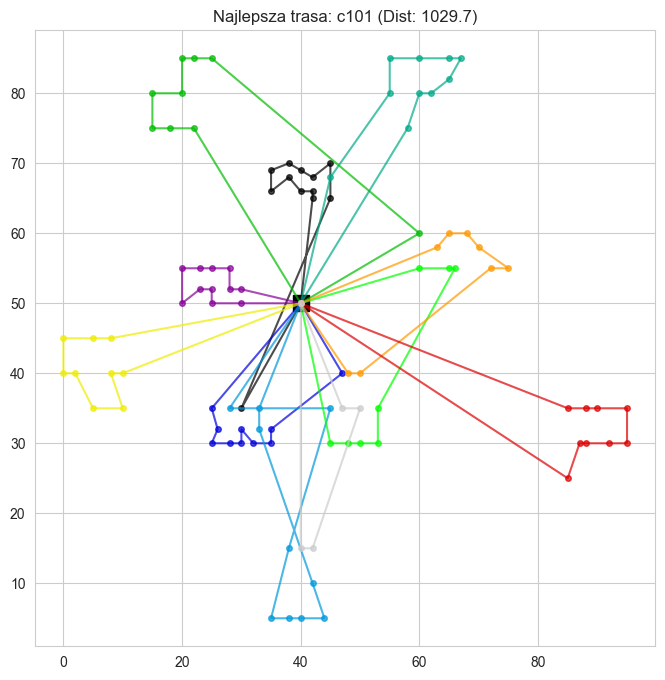

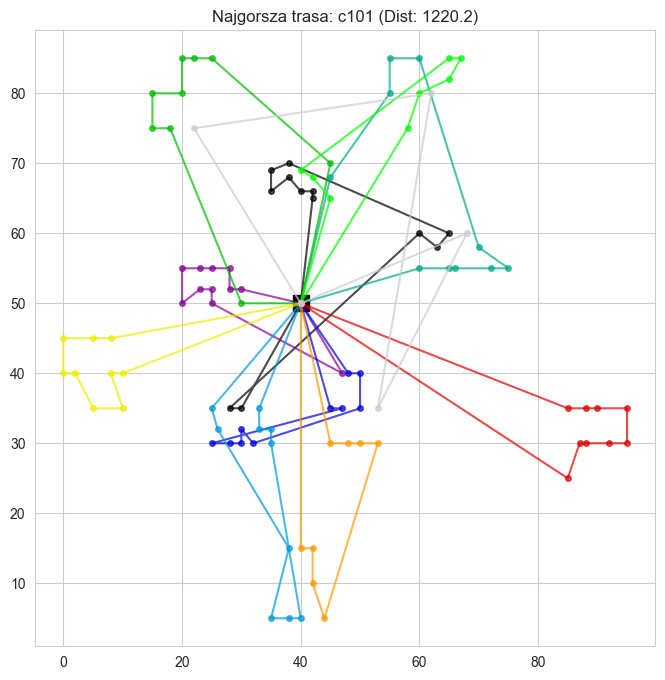

In [60]:

EXP = "Exp3_Transfer_Dominance"
VAL = 0
INST = "c101"

subset = df[(df['Experiment'] == EXP) & (df['Value'] == VAL) & (df['Instance'] == INST)]
coords = load_coords(INST)

if not subset.empty and coords:
    # Najlepszy wynik w tej serii
    best_run = subset.loc[subset['Distance'].idxmin()]
    viz_routes_notebook(best_run['Routes'], coords, f"Najlepsza trasa: {INST} (Dist: {best_run['Distance']:.1f})")
    
    # Najgorszy wynik w tej serii
    worst_run = subset.loc[subset['Distance'].idxmax()]
    viz_routes_notebook(worst_run['Routes'], coords, f"Najgorsza trasa: {INST} (Dist: {worst_run['Distance']:.1f})")

### Exp4_Swap_Role

rc101

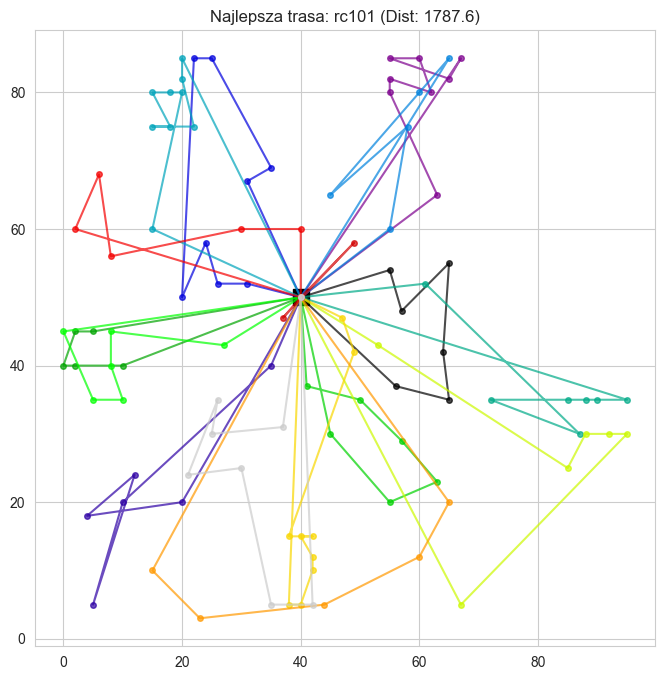

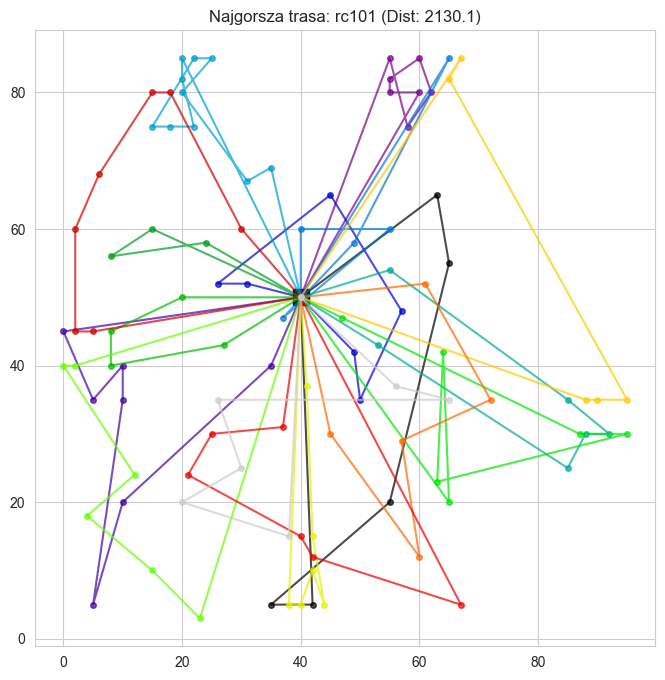

In [65]:

EXP = "Exp4_Swap_Role"
VAL = 0
INST = "rc101"

subset = df[(df['Experiment'] == EXP) & (df['Value'] == VAL) & (df['Instance'] == INST)]
coords = load_coords(INST)

if not subset.empty and coords:
    # Najlepszy wynik w tej serii
    best_run = subset.loc[subset['Distance'].idxmin()]
    viz_routes_notebook(best_run['Routes'], coords, f"Najlepsza trasa: {INST} (Dist: {best_run['Distance']:.1f})")
    
    # Najgorszy wynik w tej serii
    worst_run = subset.loc[subset['Distance'].idxmax()]
    viz_routes_notebook(worst_run['Routes'], coords, f"Najgorsza trasa: {INST} (Dist: {worst_run['Distance']:.1f})")

r101

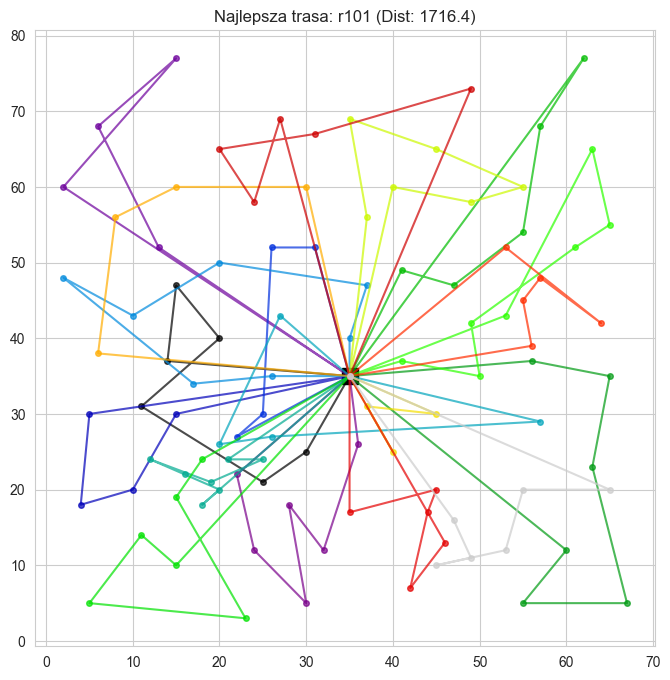

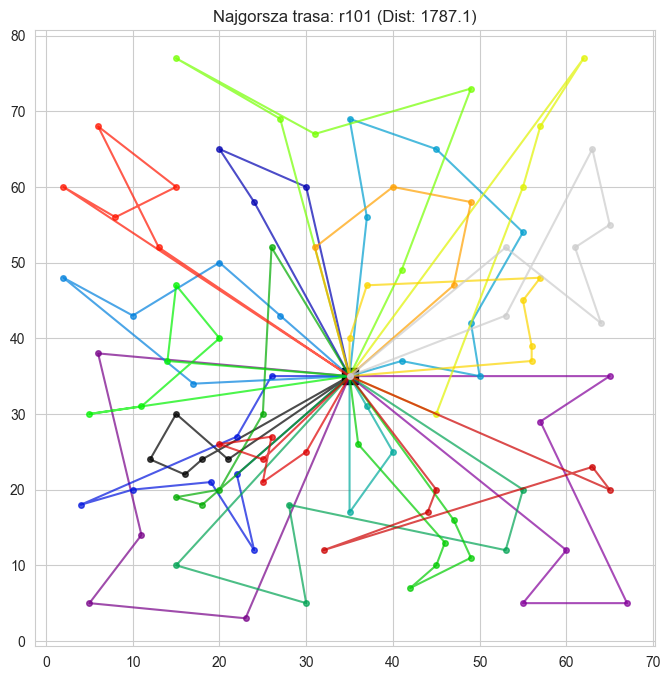

In [69]:

EXP = "Exp4_Swap_Role"
VAL = 3
INST = "r101"

subset = df[(df['Experiment'] == EXP) & (df['Value'] == VAL) & (df['Instance'] == INST)]
coords = load_coords(INST)

if not subset.empty and coords:
    # Najlepszy wynik w tej serii
    best_run = subset.loc[subset['Distance'].idxmin()]
    viz_routes_notebook(best_run['Routes'], coords, f"Najlepsza trasa: {INST} (Dist: {best_run['Distance']:.1f})")
    
    # Najgorszy wynik w tej serii
    worst_run = subset.loc[subset['Distance'].idxmax()]
    viz_routes_notebook(worst_run['Routes'], coords, f"Najgorsza trasa: {INST} (Dist: {worst_run['Distance']:.1f})")

c101

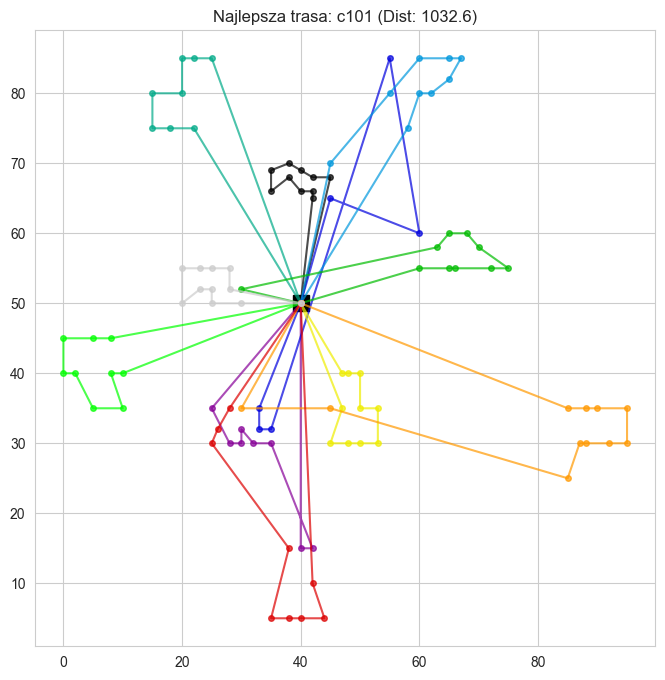

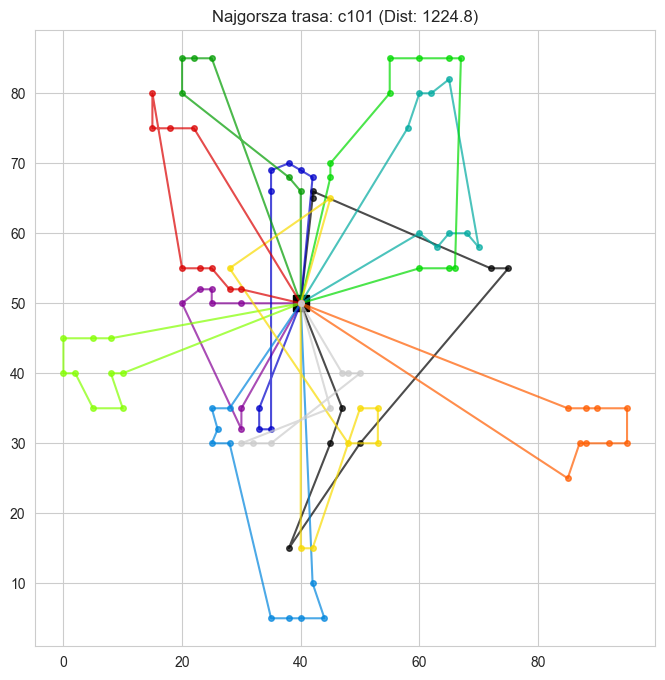

In [73]:

EXP = "Exp4_Swap_Role"
VAL = 3
INST = "c101"

subset = df[(df['Experiment'] == EXP) & (df['Value'] == VAL) & (df['Instance'] == INST)]
coords = load_coords(INST)

if not subset.empty and coords:
    # Najlepszy wynik w tej serii
    best_run = subset.loc[subset['Distance'].idxmin()]
    viz_routes_notebook(best_run['Routes'], coords, f"Najlepsza trasa: {INST} (Dist: {best_run['Distance']:.1f})")
    
    # Najgorszy wynik w tej serii
    worst_run = subset.loc[subset['Distance'].idxmax()]
    viz_routes_notebook(worst_run['Routes'], coords, f"Najgorsza trasa: {INST} (Dist: {worst_run['Distance']:.1f})")